## Gradient Descent.
Consider the function $𝑓(𝑥_1, 𝑥_2) = 𝑥_1^2 + 25𝑥_2^2$

You are required to estimate the parameters of this function (i.e., [1, 25]) by completing the following tasks.

**Visualize the function**: Using NumPy and MatplotLib, draw the contour plot of $𝑓(𝑥_1, 𝑥_2)$. This function is parameterized by $𝒘^∗ = [𝑤_1^∗,𝑤_2^∗] = [1, 25]$.
* You can use the following ranges for both coordinates for the plot: $𝑥_𝑖 ∈ [−10, 10]$ (500 points should suffice).
* The MatplotLib function `contour()`, and the NumPy function `meshgrid()` should come in handy.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def f(x1, x2):
  return x1**2 + 25 * x2**2

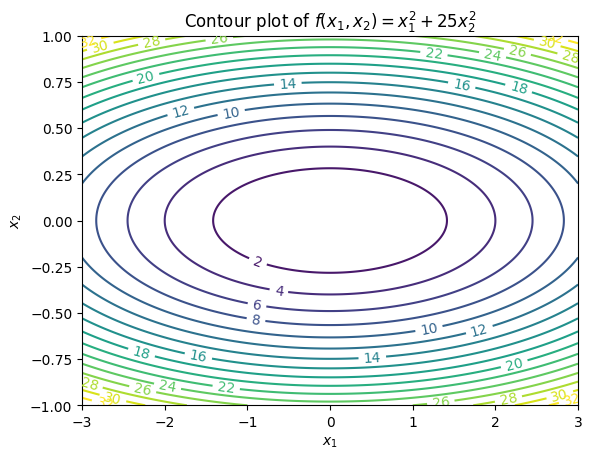

In [22]:
# Exactly as shown in sample output
x1_vals = np.linspace(-3, 3, 500)
x2_vals = np.linspace(-1, 1, 500)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2)

contour = plt.contour(X1, X2, Z, levels=np.arange(0, 34, 2))
plt.clabel(contour)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Contour plot of $f(x_1, x_2) = x_1^2 + 25x_2^2$')
plt.show()

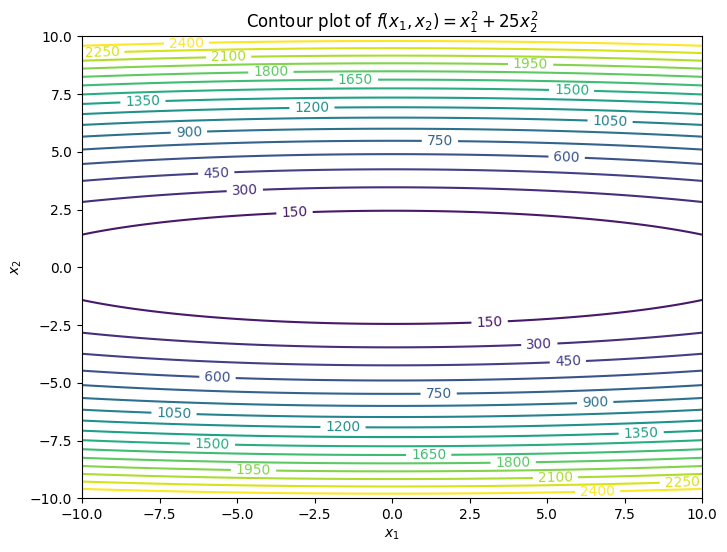

In [23]:
# Using requested ranges
x1_vals = np.linspace(-10, 10, 500)
x2_vals = np.linspace(-10, 10, 500)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2)

plt.figure(figsize=(8, 6))
contour = plt.contour(X1, X2, Z, levels=np.arange(0, 2500, 150))
plt.clabel(contour)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Contour plot of $f(x_1, x_2) = x_1^2 + 25x_2^2$')
plt.show()

**Noisy observations**: generate 1,000 noisy observations of the function, where the observations of the function are defined by $y = f(x_1, x_2) + 𝒩(0, 𝜎^2)$.
* Here, the noise is Gaussian with variance = 1.5. Set NumPy’s `random_seed = 101` to ensure reproducibility.
* Generate the data set using 1,000 independent random samples of $x_1 ~ Uniform([0,3])$ and $x_2 ∼ Uniform([0,1])$

In [24]:
np.random.seed(101)
n_samples = 1000
x1_samples = np.random.uniform(0, 3, n_samples)
x2_samples = np.random.uniform(0, 1, n_samples)
f_values = f(x1_samples, x2_samples)
noise = np.random.normal(0, np.sqrt(1.5), n_samples)
y_values = f_values + noise

**Gradient descent trajectories**: generate the trajectories of (a) batch gradient descent, (b) minibatch gradient descent (use minibatch size = 20), and (c) stochastic gradient descent. Plot the trajectories superimposed on the contours of loss function of batch gradient descent.
* For simplicity, assume you have a model of the form $\hat{y} = w_1x_1^2+w_2x_2^2$, and are using squared loss $(y-\hat{y})^2$ as the loss function.
* Remember that minibatches are chosen *randomly* in each iteration with replacement.
* Use $[1.0,1.0]$ as the initial condition and $\eta = 4 × 10^{−2}$ for batch and minibatch GD. For SGD, use $\eta = 5 × 10^{−4}$ (to prevent excessive dithering)

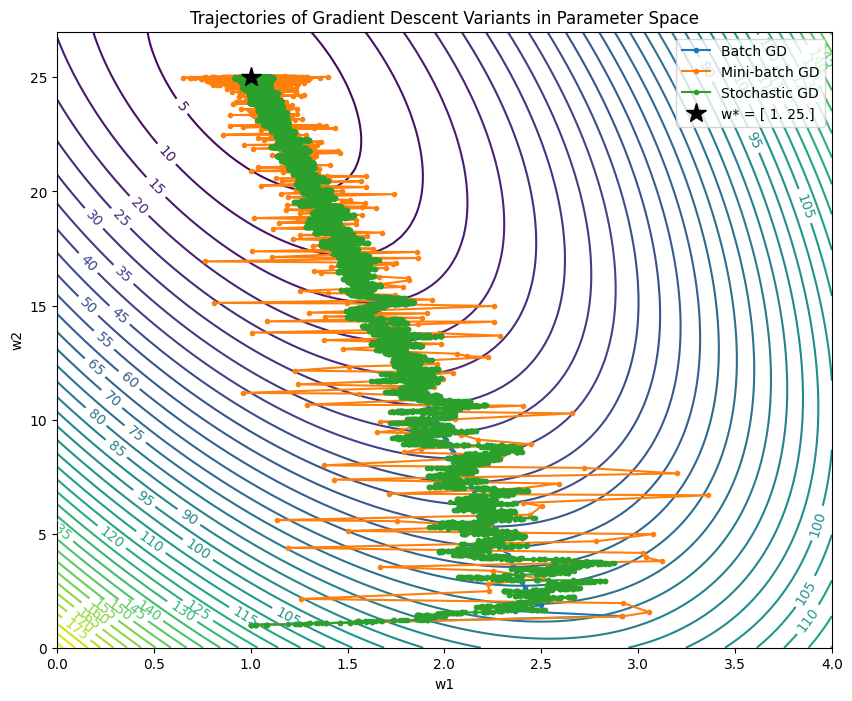

Final Batch GD weights: [ 1.0150514  24.97697101]
Final Mini-batch GD weights: [ 1.00005988 24.99956704]
Final Stochastic GD weights: [ 1.00077328 25.00033917]


In [25]:
w_init = np.array([1.0, 1.0])
w_star = np.array([1.0, 25.0])
tolerance = 1e-3
eta_batch = 4e-2
eta_mini_batch = 4e-2
eta_stochastic = 5e-4
mini_batch_size = 20
max_iter = 100000

def predict(w, x1, x2):
    return w[0] * x1**2 + w[1] * x2**2

def loss(w, x1, x2, y):
    y_hat = predict(w, x1, x2)
    return np.mean((y - y_hat)**2)

def gradient(w, x1, x2, y):
    y_hat = predict(w, x1, x2)
    error = y - y_hat
    dw1 = -2 * np.mean(error * x1**2)
    dw2 = -2 * np.mean(error * x2**2)
    return np.array([dw1, dw2])

# Batch GD
def batch_gradient_descent(w, x1, x2, y, eta, max_iter):
    history = [w.copy()]
    w_t = w.copy()
    for _ in range(max_iter):
        grad = gradient(w_t, x1, x2, y)
        w_t -= eta * grad
        history.append(w_t.copy())
        if np.linalg.norm(w_t - w_star) < tolerance:
            return np.array(history)
    return np.array(history)

# Mini-batch GD
def create_mini_batches(x1, x2, y, batch_size):
    n_samples = len(x1)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    x1_shuffled = x1[indices]
    x2_shuffled = x2[indices]
    y_shuffled = y[indices]
    for i in range(0, n_samples, batch_size):
        x1_batch = x1_shuffled[i:i+batch_size]
        x2_batch = x2_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        yield x1_batch, x2_batch, y_batch
        
def mini_batch_gradient_descent(w, x1, x2, y, eta, batch_size, max_iter):
    history = [w.copy()]
    w_t = w.copy()
    for _ in range(max_iter):
        for x1_batch, x2_batch, y_batch in create_mini_batches(x1, x2, y, batch_size):
            grad = gradient(w_t, x1_batch, x2_batch, y_batch)
            w_t -= eta * grad
            history.append(w_t.copy())
            if np.linalg.norm(w_t - w_star) < tolerance:
                return np.array(history)
    return np.array(history)

# Stochastic GD
def stochastic_gradient_descent(w, x1, x2, y, eta, max_iter):
    history = [w.copy()]
    w_t = w.copy()
    indices = np.arange(len(x1))
    for _ in range(max_iter):
        np.random.shuffle(indices)
        x1, x2, y = x1[indices], x2[indices], y[indices]
        for i in range(len(x1)):
            grad = gradient(w_t, x1[i], x2[i], y[i])
            w_t -= eta * grad
            history.append(w_t.copy())
            if np.linalg.norm(w_t - w_star) < tolerance:
                return np.array(history)
    return np.array(history)

batch = batch_gradient_descent(w_init, x1_samples, x2_samples, y_values, eta_batch, max_iter)
mini_batch = mini_batch_gradient_descent(w_init, x1_samples, x2_samples, y_values, eta_mini_batch, mini_batch_size, max_iter)
stochastic = stochastic_gradient_descent(w_init, x1_samples, x2_samples, y_values, eta_stochastic, max_iter)

# Plotting
w1_grid = np.linspace(0, 4, 100)
w2_grid = np.linspace(0, 27, 100)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
Loss = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Loss[i, j] = loss(np.array([W1[i, j], W2[i, j]]), x1_samples, x2_samples, y_values)

plt.figure(figsize=(10, 8))
contour = plt.contour(W1, W2, Loss, levels=np.arange(0, 200, 5))
plt.clabel(contour)
plt.plot(batch[:, 0], batch[:, 1], '.-', label='Batch GD')
plt.plot(mini_batch[:, 0], mini_batch[:, 1], '.-', label='Mini-batch GD')
plt.plot(stochastic[:, 0], stochastic[:, 1], '.-', label='Stochastic GD')
plt.plot(1, 25, 'k*', markersize=15, label='w* = [ 1. 25.]')
plt.xlabel('w1')
plt.ylabel('w2')
plt.title('Trajectories of Gradient Descent Variants in Parameter Space')
plt.legend(loc='upper right')
plt.show()

print(f"Final Batch GD weights: {batch[-1]}")
print(f"Final Mini-batch GD weights: {mini_batch[-1]}")
print(f"Final Stochastic GD weights: {stochastic[-1]}")

**Convergence**: how many iterations does each of the three algorithms require to come within an accuracy of $10^{−3}$? That is, after how many iterations is $‖w_t − w^*‖_2 < 10^{−3}$ for each of the three algorithms, where $w^* = [1, 25]$?

In [30]:
if len(batch) < max_iter: 
    print(f"Batch Gradient Descent converged in {len(batch)} iterations")
else:
    print(f"Batch Gradient Descent did not converge within {len(batch)-1} iterations")
if len(mini_batch) < max_iter * n_samples / mini_batch_size:
    print(f"Mini-batch Gradient Descent converged in {len(mini_batch)} iterations")
else:
    print(f"Mini-batch Gradient Descent did not converge within {len(mini_batch)-1} iterations")
if len(stochastic) < max_iter * n_samples:
    print(f"Stochastic Gradient Descent converged in {len(stochastic)} iterations")
else:
    print(f"Stochastic Gradient Descent did not converge within {len(stochastic)-1} iterations")

Batch Gradient Descent did not converge within 100000 iterations
Mini-batch Gradient Descent converged in 1931 iterations
Stochastic Gradient Descent converged in 380225 iterations


# Gradients and Chain Rules.
Find the gradient of the following functions at the given points (you might have to use some of the chain rules discussed in class).
* $f(x, y, z) = (2x^2 + cos(yz) − 3z)^2$ at $[x, y, z] = [2, \pi, 1]$
* $f(x, y, z) = cos(x)cosh(y)$, where $cosh(y) = \frac{e^y+e^{-y}}{2}$ at $[x, y] = [\frac{\pi}{2}, ln(2)]$.

Note that both functions above are functions of three variables $x, y, z$.

In [27]:
import sympy as sp
x, y, z = sp.symbols('x y z')

### Derivative Calculation
$f(x, y, z) = (2x^2 + \cos(yz) - 3z)^2$ at $[x, y, z] = [2, \pi, 1]$

Define $g(x, y, z) = 2x^2 + \cos(yz) - 3z$, so that $f(x, y, z) = [g(x, y, z)]^2$

First, calculate $g(2, \pi, 1)$:
$g(2, \pi, 1) = 2(2^2) + \cos(\pi \cdot 1) - 3(1) = 8 - 1 - 3 = 4$

Find the partial derivatives of $g$ with respect to each variable:

$\frac{\partial g}{\partial x} = 4x$

$\frac{\partial g}{\partial y} = -z\sin(yz)$

$\frac{\partial g}{\partial z} = -y\sin(yz) - 3$

Evaluate at $(2, \pi, 1)$:

$\frac{\partial g}{\partial x}\bigg|_{(2,\pi,1)} = 4(2) = 8$

$\frac{\partial g}{\partial y}\bigg|_{(2,\pi,1)} = -1\sin(\pi) = 0$

$\frac{\partial g}{\partial z}\bigg|_{(2,\pi,1)} = -\pi\sin(\pi) - 3 = -3$

Using the chain rule for $f = g^2$, $\frac{\partial f}{\partial u} = 2g \cdot \frac{\partial g}{\partial u}$ for any variable $u$:

$\frac{\partial f}{\partial x} = 2g \cdot \frac{\partial g}{\partial x} = 2(4)(8) = 64$

$\frac{\partial f}{\partial y} = 2g \cdot \frac{\partial g}{\partial y} = 2(4)(0) = 0$

$\frac{\partial f}{\partial z} = 2g \cdot \frac{\partial g}{\partial z} = 2(4)(-3) = -24$

Therefore, the gradient of $f$ at point $[2, \pi, 1]$ is $\nabla f = [64, 0, -24]$.

In [28]:
# Define function
f1 = (2*x**2 + sp.cos(y*z) - 3*z)**2

# Calculate partial derivatives
df1_dx = sp.diff(f1, x)
df1_dy = sp.diff(f1, y)
df1_dz = sp.diff(f1, z)

# Evaluate at the point [2, pi, 1]
grad_f1_x = df1_dx.subs([(x, 2), (y, sp.pi), (z, 1)])
grad_f1_y = df1_dy.subs([(x, 2), (y, sp.pi), (z, 1)])
grad_f1_z = df1_dz.subs([(x, 2), (y, sp.pi), (z, 1)])

print("Function 1: f(x, y, z) = (2x^2 + cos(yz) - 3z)^2 at [x, y, z] = [2, π, 1]")
print(f"f(2, π, 1) = {f1.subs([(x, 2), (y, sp.pi), (z, 1)])}")
print(f"Gradient at f(2, π, 1) = [{grad_f1_x}, {grad_f1_y}, {grad_f1_z}]")


Function 1: f(x, y, z) = (2x^2 + cos(yz) - 3z)^2 at [x, y, z] = [2, π, 1]
f(2, π, 1) = 16
Gradient at f(2, π, 1) = [64, 0, -24]


### Derivative Calculation

$f(x, y, z) = \cos(x)\cosh(y)$ at $[x, y] = [\frac{\pi}{2}, \ln(2)]$

Where $\cosh(y) = \frac{e^y+e^{-y}}{2}$ is the hyperbolic cosine function.

Evaluate $\cosh(\ln(2))$:
$\cosh(\ln(2)) = \frac{e^{\ln(2)}+e^{-\ln(2)}}{2} = \frac{2 + \frac{1}{2}}{2} = \frac{2.5}{2} = 1.25$

The hyperbolic sine function is:
$\sinh(y) = \frac{e^y-e^{-y}}{2}$
$\sinh(\ln(2)) = \frac{2 - \frac{1}{2}}{2} = \frac{1.5}{2} = 0.75$

Find the partial derivatives with respect to each variable:

$\frac{\partial f}{\partial x} = -\sin(x)\cosh(y)$

$\frac{\partial f}{\partial y} = \cos(x)\sinh(y)$

$\frac{\partial f}{\partial z} = 0$ (since the function doesn't depend on $z$)

At $[x, y] = [\frac{\pi}{2}, \ln(2)]$:

$\frac{\partial f}{\partial x} = -\sin(\frac{\pi}{2})\cosh(\ln(2)) = -1 \cdot 1.25 = -1.25$

$\frac{\partial f}{\partial y} = \cos(\frac{\pi}{2})\sinh(\ln(2)) = 0 \cdot 0.75 = 0$

Therefore, the gradient of $f$ at point $[\frac{\pi}{2}, \ln(2)]$ is $\nabla f = [-1.25, 0, 0]$.

In [29]:
# Define function
f2 = sp.cos(x) * ((sp.exp(y) + sp.exp(-y))/2)

# Calculate partial derivatives
df2_dx = sp.diff(f2, x)
df2_dy = sp.diff(f2, y)
df2_dz = sp.diff(f2, z)

# Evaluate at the point [pi/2, ln(2)]
grad_f2_x = df2_dx.subs([(x, sp.pi/2), (y, sp.log(2))])
grad_f2_y = df2_dy.subs([(x, sp.pi/2), (y, sp.log(2))])
grad_f2_z = df2_dz.subs([(x, sp.pi/2), (y, sp.log(2))])

print("Function 2: f(x, y, z) = cos(x)cosh(y) at [x, y] = [π/2, ln(2)]")
print(f"f(π/2, ln(2)) = {f2.subs([(x, sp.pi/2), (y, sp.log(2))])}")
print(f"Gradient at f(π/2, ln(2)) = [{grad_f2_x}, {grad_f2_y}, {grad_f2_z}]")

Function 2: f(x, y, z) = cos(x)cosh(y) at [x, y] = [π/2, ln(2)]
f(π/2, ln(2)) = 0
Gradient at f(π/2, ln(2)) = [-5/4, 0, 0]
